# Estimating the Effect of Job-Training Programs on Earnings
## Lalonde / Dehejia-Wahba Dataset — Causal Inference Analysis
**Author:** Joshua Carbajal | University of Chicago — Causal Models

---

This notebook was created with the aid of Claude

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
import xgboost as xgb
from econml.dml import CausalForestDML
import dowhy.datasets

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Known RCT benchmark — the "right answer" we compare against
RCT_BENCHMARK = 1794

COVARIATES = ['age', 'educ', 'black', 'hisp', 'married', 'nodegree', 're74', 're75']
TREATMENT = 'treat'
OUTCOME = 're78'

## 1. Load Data

Data loaded directly from the NBER source via `dowhy.datasets`.
- `lalonde_dataset()` — NSW RCT (treated + RCT controls)
- `psid_dataset()` — CPS-1 non-experimental comparison group

We combine the NSW treated participants with the CPS-1 controls to replicate
the hard observational estimation environment from Lalonde (1986).

In [2]:
# NSW RCT data
nsw = dowhy.datasets.lalonde_dataset()
nsw = nsw.rename(columns={'nodegr': 'nodegree'})
nsw['treat'] = nsw['treat'].astype(int)

# CPS-1 comparison group
cps1 = dowhy.datasets.psid_dataset()
cps1 = cps1.rename(columns={'nodegr': 'nodegree'})
cps1['treat'] = cps1['treat'].astype(int)

# Combine: NSW treated + CPS-1 controls
df = pd.concat([nsw[nsw['treat'] == 1], cps1], ignore_index=True)

print(f"Combined sample: {len(df)} observations")
print(f"  Treated (NSW):    {df['treat'].sum()}")
print(f"  Controls (CPS-1): {(df['treat'] == 0).sum()}")

Combined sample: 2675 observations
  Treated (NSW):    185
  Controls (CPS-1): 2490


## 2. Exploratory Data Analysis

In [3]:
# Group means
print("Means by group:")
df.groupby('treat')[COVARIATES + [OUTCOME]].mean().round(2)

Means by group:


,age,educ,black,hisp,married,nodegree,re74,re75,re78
treat,,,,,,,,,
0,34.85,12.12,0.25,0.03,0.87,0.31,19428.75,19063.34,21553.92
1,25.82,10.35,0.84,0.06,0.19,0.71,2095.57,1532.06,6349.14


In [6]:
# Standardized mean differences
def smd_unweighted(col, data):
    t = data.loc[data[TREATMENT] == 1, col]
    c = data.loc[data[TREATMENT] == 0, col]
    pooled_sd = np.sqrt((t.var() + c.var()) / 2)
    return (t.mean() - c.mean()) / pooled_sd if pooled_sd > 0 else 0.0

smd_df = pd.DataFrame({
    'Treated Mean': df[df[TREATMENT]==1][COVARIATES].mean().round(1),
    'Control Mean':  df[df[TREATMENT]==0][COVARIATES].mean().round(1),
    'SMD':           [round(smd_unweighted(c, df), 3) for c in COVARIATES]
})
print("Standardized Mean Differences (before adjustment):")
print(smd_df.to_string())

Standardized Mean Differences (before adjustment):
          Treated Mean  Control Mean    SMD
age               25.8          34.9 -1.009
educ              10.3          12.1 -0.681
black              0.8           0.3  1.480
hisp               0.1           0.0  0.129
married            0.2           0.9 -1.842
nodegree           0.7           0.3  0.879
re74            2095.6       19428.7 -1.718
re75            1532.1       19063.3 -1.774


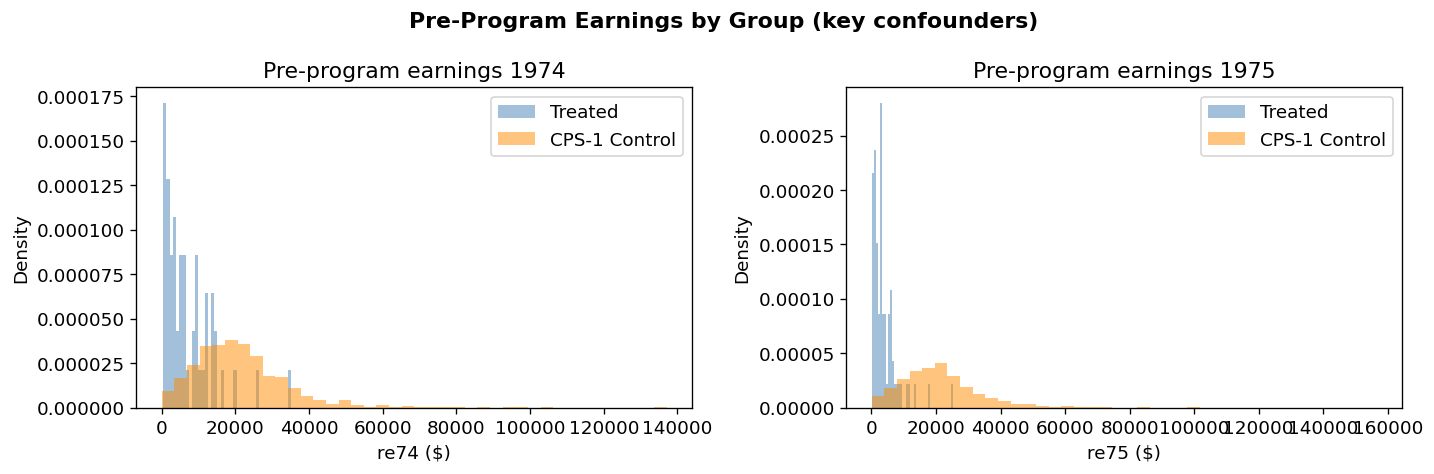

In [7]:
# Pre-program earnings distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, year in zip(axes, ['re74', 're75'], ['1974', '1975']):
    for grp, label, color in [(1, 'Treated', 'steelblue'), (0, 'CPS-1 Control', 'darkorange')]:
        vals = df.loc[(df[TREATMENT] == grp) & (df[col] > 0), col]
        ax.hist(vals, bins=40, alpha=0.5, color=color, density=True, label=label)
    ax.set_title(f'Pre-program earnings {year}')
    ax.set_xlabel(f're{year[-2:]} ($)')
    ax.set_ylabel('Density')
    ax.legend()
plt.suptitle('Pre-Program Earnings by Group (key confounders)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/eda_preearnings.png', bbox_inches='tight')
plt.show()

## 3. Method 1: Inverse Probability Weighting (IPW)

Propensity scores estimated via logistic regression. Stabilized weights applied.
Extreme scores trimmed at the 1st/99th percentile to handle CPS-1 positivity violations.

In [8]:
X = df[COVARIATES].values
T = df[TREATMENT].values
Y = df[OUTCOME].values

# Estimate propensity scores
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
ps_model = LogisticRegression(max_iter=1000, C=1.0)
ps_model.fit(X_scaled, T)
ps = ps_model.predict_proba(X_scaled)[:, 1]

# Trim extreme propensity scores (1st/99th percentile)
trim_lo = np.percentile(ps, 1)
trim_hi = np.percentile(ps, 99)
mask    = (ps >= trim_lo) & (ps <= trim_hi)

T_t, Y_t, ps_t = T[mask], Y[mask], ps[mask]
X_t = X[mask]
df_t = df[mask].copy().reset_index(drop=True)
df_t['ps'] = ps_t

print(f"Trimmed {(~mask).sum()} observations ({(~mask).mean():.1%}) with extreme propensity scores.")

Trimmed 54 observations (2.0%) with extreme propensity scores.


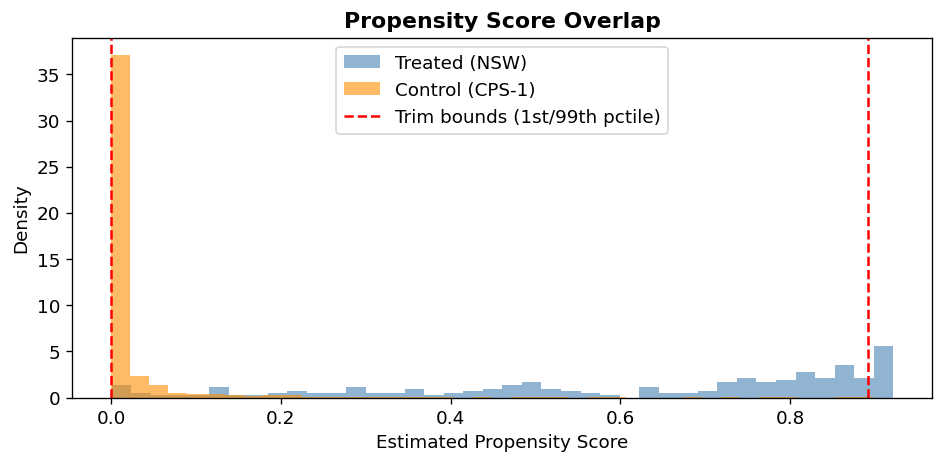

In [9]:
# Propensity score overlap plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ps[T==1], bins=40, alpha=0.6, color='steelblue', density=True, label='Treated (NSW)')
ax.hist(ps[T==0], bins=40, alpha=0.6, color='darkorange', density=True, label='Control (CPS-1)')
ax.axvline(trim_lo, color='red', linestyle='--', linewidth=1.5, label='Trim bounds (1st/99th pctile)')
ax.axvline(trim_hi, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Estimated Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Propensity Score Overlap', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/ipw_overlap.png', bbox_inches='tight')
plt.show()

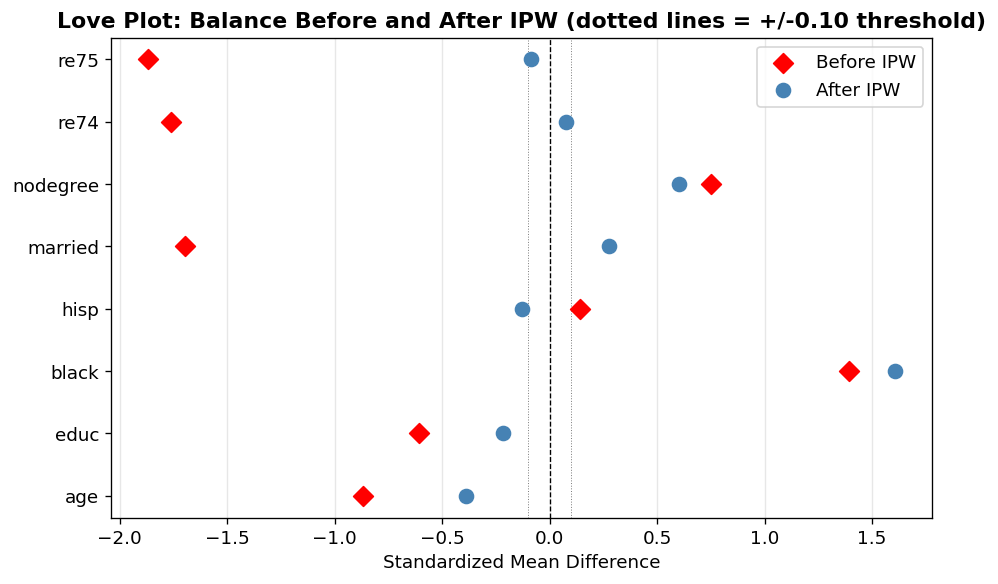

Post-weighting SMDs:
  age          -0.390  IMBALANCED
  educ         -0.218  IMBALANCED
  black        +1.607  IMBALANCED
  hisp         -0.129  IMBALANCED
  married      +0.277  IMBALANCED
  nodegree     +0.604  IMBALANCED
  re74         +0.075  OK
  re75         -0.084  OK


In [11]:
# Stabilized IPW weights
p_treat = T_t.mean()
weights  = np.where(T_t == 1, p_treat / ps_t, (1 - p_treat) / (1 - ps_t))
df_t['ipw_weight'] = weights

# Love plot — balance before and after weighting
def smd_weighted(col, data, weight_col):
    t = data[data[TREATMENT] == 1]
    c = data[data[TREATMENT] == 0]
    t_mean = np.average(t[col], weights=t[weight_col])
    c_mean = np.average(c[col], weights=c[weight_col])
    pooled_sd = np.sqrt((data[data[TREATMENT]==1][col].var() +
                         data[data[TREATMENT]==0][col].var()) / 2)
    return (t_mean - c_mean) / pooled_sd if pooled_sd > 0 else 0.0

smd_before = [smd_unweighted(c, df_t) for c in COVARIATES]
smd_after  = [smd_weighted(c, df_t, 'ipw_weight') for c in COVARIATES]

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(COVARIATES))
ax.scatter(smd_before, y, color='red',       marker='D', s=70, zorder=3, label='Before IPW')
ax.scatter(smd_after,  y, color='steelblue', marker='o', s=70, zorder=3, label='After IPW')
ax.axvline(0,    color='black', linewidth=0.8, linestyle='--')
ax.axvline( 0.1, color='gray',  linewidth=0.6, linestyle=':')
ax.axvline(-0.1, color='gray',  linewidth=0.6, linestyle=':')
ax.set_yticks(y)
ax.set_yticklabels(COVARIATES)
ax.set_xlabel('Standardized Mean Difference')
ax.set_title('Love Plot: Balance Before and After IPW (dotted lines = +/-0.10 threshold)', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/ipw_love_plot.png', bbox_inches='tight')
plt.show()

print("Post-weighting SMDs:")
for cov, after in zip(COVARIATES, smd_after):
    flag = "OK" if abs(after) < 0.10 else "IMBALANCED"
    print(f"  {cov:<12} {after:+.3f}  {flag}")

In [12]:
# IPW ATE estimate with bootstrap CIs
def ipw_ate(T, Y, ps, p_treat):
    w   = np.where(T == 1, p_treat / ps, (1 - p_treat) / (1 - ps))
    mu1 = np.sum(Y * T * w) / np.sum(T * w)
    mu0 = np.sum(Y * (1-T) * w) / np.sum((1-T) * w)
    return mu1 - mu0

ate_ipw = ipw_ate(T_t, Y_t, ps_t, p_treat)

np.random.seed(42)
boot_ates = [ipw_ate(T_t[idx:=np.random.choice(len(T_t), len(T_t), replace=True)],
                     Y_t[idx], ps_t[idx], p_treat)
             for _ in range(500)]
ipw_lo = np.percentile(boot_ates, 2.5)
ipw_hi = np.percentile(boot_ates, 97.5)

print(f"IPW ATE:  ${ate_ipw:,.0f}  (95% CI: ${ipw_lo:,.0f} to ${ipw_hi:,.0f})")
print(f"RCT benchmark: ${RCT_BENCHMARK:,}  |  Bias: ${ate_ipw - RCT_BENCHMARK:+,.0f}")

IPW ATE:  $-6,557  (95% CI: $-15,641 to $8,594)
RCT benchmark: $1,794  |  Bias: $-8,351


## 4. Method 2: Doubly Robust Estimation (AIPW)

XGBoost outcome model with 5-fold cross-fitting. Doubly robust: consistent if
either the propensity score model or the outcome model is correctly specified.

In [14]:
X = df[COVARIATES].values
T = df[TREATMENT].values.astype(float)
Y = df[OUTCOME].values
n = len(Y)

K  = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)
scaler = StandardScaler()

mu1_hat = np.zeros(n)
mu0_hat = np.zeros(n)
ps_hat  = np.zeros(n)

xgb_params = dict(n_estimators=300, max_depth=5, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)

print(f"Running {K}-fold cross-fitting...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    T_tr, Y_tr  = T[train_idx], Y[train_idx]

    X_tr_sc  = scaler.fit_transform(X_tr)
    X_val_sc = scaler.transform(X_val)

    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_tr_sc, T_tr)
    ps_hat[val_idx] = lr.predict_proba(X_val_sc)[:, 1]

    for tv, store in [(1, mu1_hat), (0, mu0_hat)]:
        mask = (T_tr == tv)
        m = xgb.XGBRegressor(**xgb_params)
        m.fit(X_tr[mask], Y_tr[mask])
        store[val_idx] = m.predict(X_val)

    print(f"  Fold {fold}/{K} done")

# AIPW estimator
ps_c  = np.clip(ps_hat, 0.01, 0.99)
phi   = (mu1_hat - mu0_hat
         + T * (Y - mu1_hat) / ps_c
         - (1 - T) * (Y - mu0_hat) / (1 - ps_c))

ate_aipw = phi.mean()
se_aipw  = phi.std() / np.sqrt(n)
aipw_lo  = ate_aipw - 1.96 * se_aipw
aipw_hi  = ate_aipw + 1.96 * se_aipw

print(f"AIPW ATE: ${ate_aipw:,.0f}  (95% CI: ${aipw_lo:,.0f} to ${aipw_hi:,.0f})")
print(f"RCT benchmark: ${RCT_BENCHMARK:,}  |  Bias: ${ate_aipw - RCT_BENCHMARK:+,.0f}")

Running 5-fold cross-fitting...
  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done
AIPW ATE: $-9,533  (95% CI: $-11,804 to $-7,263)
RCT benchmark: $1,794  |  Bias: $-11,327


## 5. Method 3: Causal Forest

Estimates a conditional average treatment effect (CATE) for each individual.
Implemented via EconML's `CausalForestDML` with honest splitting and 5-fold cross-fitting.
Heterogeneity examined by pre-program earnings quintile, age group, and education level.

In [16]:
X = df[COVARIATES].values
T = df[TREATMENT].values.astype(float)
Y = df[OUTCOME].values

print("Fitting Causal Forest (this may take a minute)...")
cf = CausalForestDML(
    n_estimators=500,
    min_samples_leaf=10,
    honest=True,
    inference=True,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
cf.fit(Y, T, X=X)
print("Done.")

# Population ATE
ate_cf            = cf.ate(X)
cf_lo, cf_hi      = cf.ate_interval(X, alpha=0.05)

print(f"Causal Forest ATE: ${ate_cf:,.0f}  (95% CI: ${cf_lo:,.0f} to ${cf_hi:,.0f})")
print(f"RCT benchmark: ${RCT_BENCHMARK:,}  |  Bias: ${ate_cf - RCT_BENCHMARK:+,.0f}")

Fitting Causal Forest (this may take a minute)...
Done.
Causal Forest ATE: $503  (95% CI: $-17,863 to $18,870)
RCT benchmark: $1,794  |  Bias: $-1,291


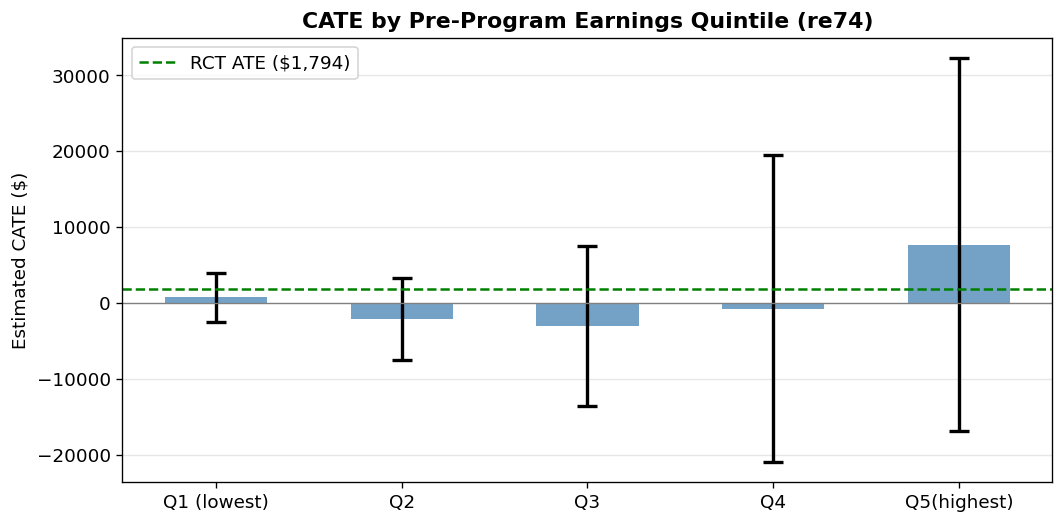

In [18]:
# Individual CATE estimates
cate              = cf.effect(X)
cate_lo, cate_hi  = cf.effect_interval(X, alpha=0.05)
df['cate']        = cate
df['cate_lo']     = cate_lo
df['cate_hi']     = cate_hi

# CATE by pre-program earnings quintile
df['re74_quintile'] = pd.qcut(df['re74'], q=5,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5(highest)'])

q_stats = df.groupby('re74_quintile', observed=True).agg(
    cate_mean=('cate','mean'), cate_lo=('cate_lo','mean'), cate_hi=('cate_hi','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(q_stats))
ax.bar(x, q_stats['cate_mean'], color='steelblue', alpha=0.75, width=0.55)
ax.errorbar(x, q_stats['cate_mean'],
            yerr=[q_stats['cate_mean']-q_stats['cate_lo'],
                  q_stats['cate_hi']-q_stats['cate_mean']],
            fmt='none', color='black', capsize=6, capthick=2, elinewidth=2)
ax.axhline(RCT_BENCHMARK, color='green', linestyle='--', linewidth=1.5,
           label=f'RCT ATE (${RCT_BENCHMARK:,})')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(q_stats['re74_quintile'])
ax.set_ylabel('Estimated CATE ($)')
ax.set_title('CATE by Pre-Program Earnings Quintile (re74)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/cf_cate_quintile.png', bbox_inches='tight')
plt.show()

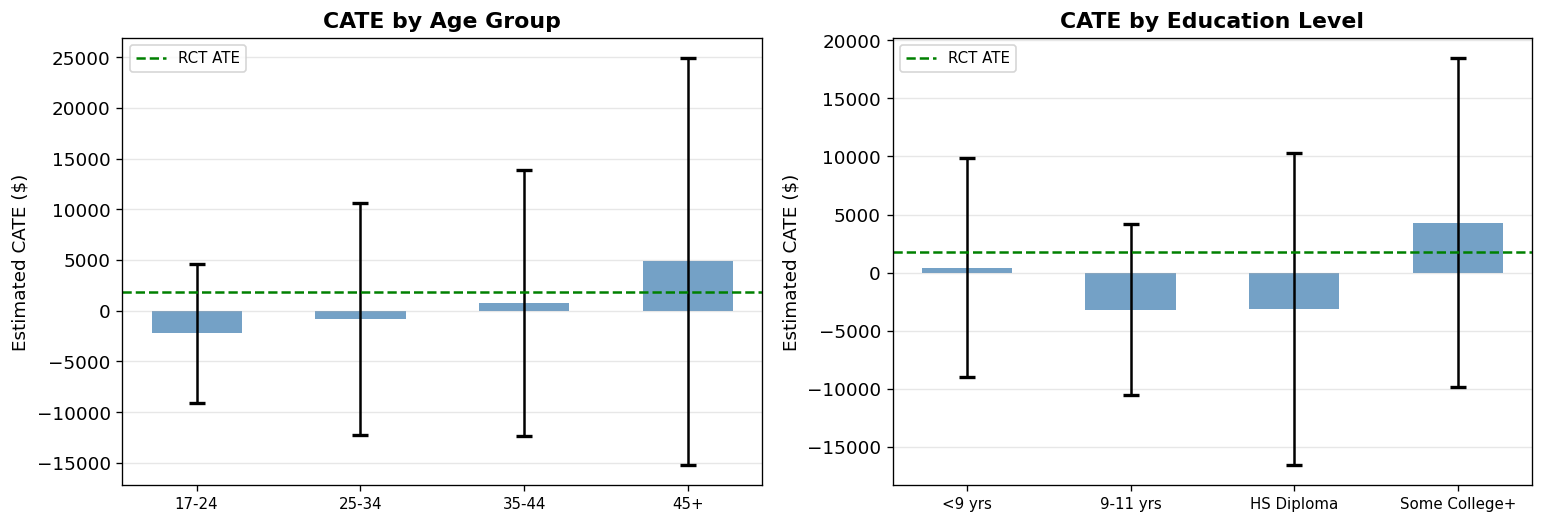

In [21]:
# CATE by age group and education level
df['age_group']  = pd.cut(df['age'],  bins=[16,24,34,44,65],
                           labels=['17-24','25-34','35-44','45+'])
df['educ_group'] = pd.cut(df['educ'], bins=[2,8,11,12,16],
                           labels=['<9 yrs','9-11 yrs','HS Diploma','Some College+'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col, title in zip(axes, ['age_group','educ_group'], ['Age Group','Education Level']):
    stats = df.groupby(col, observed=True).agg(
        cate_mean=('cate','mean'), cate_lo=('cate_lo','mean'), cate_hi=('cate_hi','mean')
    ).reset_index()
    x = np.arange(len(stats))
    ax.bar(x, stats['cate_mean'], color='steelblue', alpha=0.75, width=0.55)
    ax.errorbar(x, stats['cate_mean'],
                yerr=[stats['cate_mean']-stats['cate_lo'],
                      stats['cate_hi']-stats['cate_mean']],
                fmt='none', color='black', capsize=5, capthick=2, elinewidth=1.5)
    ax.axhline(RCT_BENCHMARK, color='green', linestyle='--', linewidth=1.5, label='RCT ATE')
    ax.set_xticks(x); ax.set_xticklabels(stats[col], fontsize=9)
    ax.set_ylabel('Estimated CATE ($)')
    ax.set_title(f'CATE by {title}', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/cf_cate_age_educ.png', bbox_inches='tight')
plt.show()

## 6. Results Comparison

All observational estimates compared against the RCT benchmark of ~$1,794.
Convergence across methods with overlapping CIs is treated as corroborating evidence.

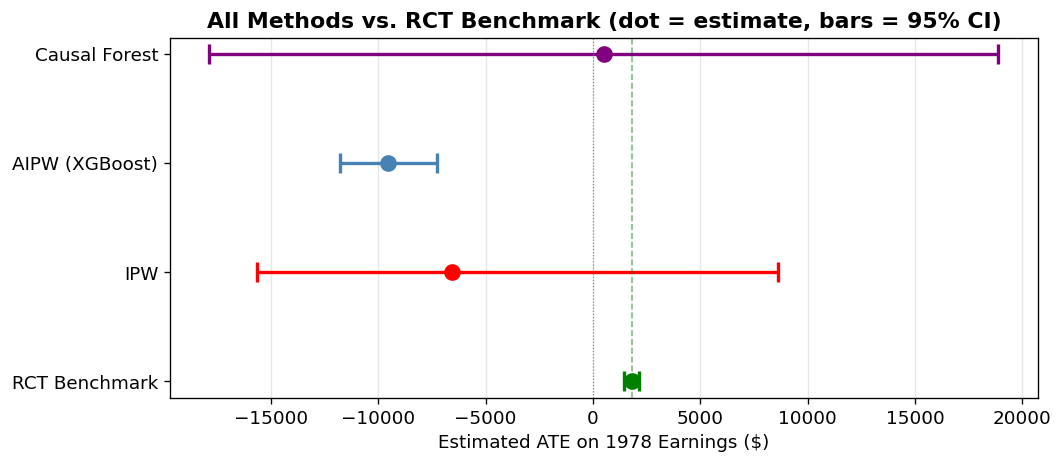

Method                      ATE     CI Lo     CI Hi      Bias  In RCT CI?
----------------------------------------------------------------------
  RCT Benchmark        $  1,794  $  1,457  $  2,131  $     +0  Yes
  IPW                  $ -6,557  $-15,641  $  8,594  $ -8,351  No
  AIPW (XGBoost)       $ -9,533  $-11,804  $ -7,263  $-11,327  No
  Causal Forest        $    503  $-17,863  $ 18,870  $ -1,291  No


In [24]:
methods   = ['RCT Benchmark', 'IPW', 'AIPW (XGBoost)', 'Causal Forest']
estimates = [RCT_BENCHMARK,    ate_ipw,  ate_aipw,         ate_cf]
lowers    = [1457,             ipw_lo,   aipw_lo,           cf_lo]
uppers    = [2131,             ipw_hi,   aipw_hi,           cf_hi]
colors    = ['green',          'red',    'steelblue',       'purple']

fig, ax = plt.subplots(figsize=(9, 4))
for i, (m, e, lo, hi, c) in enumerate(zip(methods, estimates, lowers, uppers, colors)):
    ax.errorbar(e, i, xerr=[[e-lo],[hi-e]],
                fmt='o', color=c, capsize=6, capthick=2, elinewidth=2, markersize=9)
ax.axvline(RCT_BENCHMARK, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_yticks(range(len(methods))); ax.set_yticklabels(methods)
ax.set_xlabel('Estimated ATE on 1978 Earnings ($)')
ax.set_title('All Methods vs. RCT Benchmark (dot = estimate, bars = 95% CI)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/results_comparison.png', bbox_inches='tight')
plt.show()

print(f"{'Method':<22} {'ATE':>8}  {'CI Lo':>8}  {'CI Hi':>8}  {'Bias':>8}  In RCT CI?")
print("-" * 70)
for m, e, lo, hi in zip(['RCT Benchmark','IPW','AIPW (XGBoost)','Causal Forest'],
                         estimates, lowers, uppers):
    bias  = e - RCT_BENCHMARK
    check = "Yes" if 1457 <= e <= 2131 else "No"
    print(f"  {m:<20} ${e:>7,.0f}  ${lo:>7,.0f}  ${hi:>7,.0f}  ${bias:>+7,.0f}  {check}")

## 7. Refutation Tests

Three DoWhy-style refutation tests on the AIPW estimate:
1. **Placebo treatment** — shuffled treatment should yield ATE near zero
2. **Data subset** — re-estimate on 80% subsamples to check stability
3. **Unobserved confounder** — sensitivity curve showing how strong hidden confounding must be to nullify the result

In [25]:
# Compact AIPW function for refutation loops
def run_aipw(X, T, Y, K=5, seed=42):
    n   = len(Y)
    mu1 = np.zeros(n); mu0 = np.zeros(n); ps = np.zeros(n)
    kf  = KFold(n_splits=K, shuffle=True, random_state=seed)
    sc  = StandardScaler()
    xp  = dict(n_estimators=200, max_depth=4, learning_rate=0.08,
               subsample=0.8, colsample_bytree=0.8, random_state=seed, verbosity=0)
    for tr, val in kf.split(X):
        X_tr_sc = sc.fit_transform(X[tr]); X_val_sc = sc.transform(X[val])
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_tr_sc, T[tr])
        ps[val] = lr.predict_proba(X_val_sc)[:, 1]
        for tv, store in [(1, mu1), (0, mu0)]:
            m_ = (T[tr] == tv)
            m  = xgb.XGBRegressor(**xp)
            m.fit(X[tr][m_], Y[tr][m_])
            store[val] = m.predict(X[val])
    ps_c = np.clip(ps, 0.01, 0.99)
    phi  = mu1 - mu0 + T*(Y-mu1)/ps_c - (1-T)*(Y-mu0)/(1-ps_c)
    return phi.mean(), phi.std() / np.sqrt(n)

X = df[COVARIATES].values
T = df[TREATMENT].values.astype(float)
Y = df[OUTCOME].values
n = len(Y)

Test 1: Placebo treatment (100 permutations)...
  25/100 done
  50/100 done
  75/100 done
  100/100 done


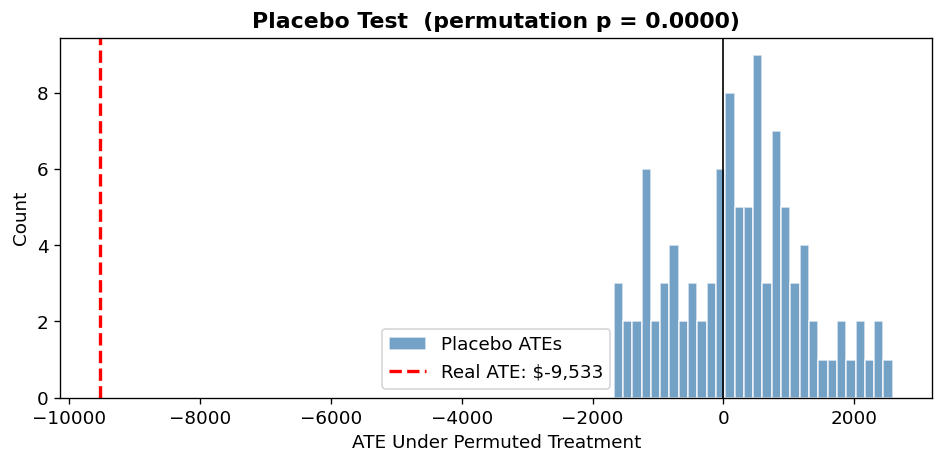

Placebo mean: $249  SD: $1,007  p = 0.0000


In [26]:
# ── Test 1: Placebo treatment ─────────────────────────────────────────────────
print("Test 1: Placebo treatment (100 permutations)...")
np.random.seed(0)
placebo_ates = []
for i in range(100):
    a, _ = run_aipw(X, np.random.permutation(T), Y, K=3, seed=i)
    placebo_ates.append(a)
    if (i+1) % 25 == 0: print(f"  {i+1}/100 done")

placebo_ates = np.array(placebo_ates)
p_value = (np.abs(placebo_ates) >= np.abs(ate_aipw)).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(placebo_ates, bins=30, color='steelblue', alpha=0.75, edgecolor='white',
        label='Placebo ATEs')
ax.axvline(ate_aipw, color='red', linestyle='--', linewidth=2,
           label=f'Real ATE: ${ate_aipw:,.0f}')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('ATE Under Permuted Treatment')
ax.set_ylabel('Count')
ax.set_title(f'Placebo Test  (permutation p = {p_value:.4f})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/refute_placebo.png', bbox_inches='tight')
plt.show()

print(f"Placebo mean: ${placebo_ates.mean():,.0f}  SD: ${placebo_ates.std():,.0f}  p = {p_value:.4f}")

Test 2: Data subset stability (50 x 80% subsamples)...
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done


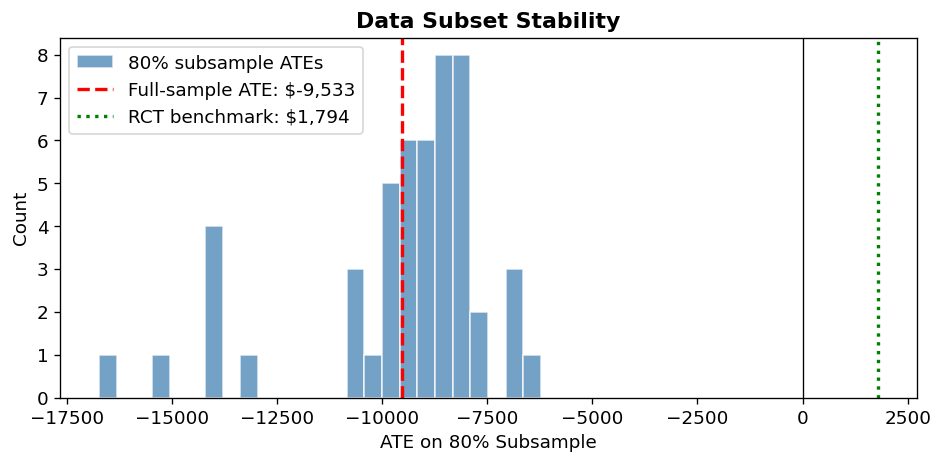

Subsample mean: $-9,529  SD: $2,232  % positive: 0%


In [27]:
# ── Test 2: Data subset stability ─────────────────────────────────────────────
print("Test 2: Data subset stability (50 x 80% subsamples)...")
np.random.seed(1)
subset_ates = []
for i in range(50):
    idx   = np.random.choice(n, size=int(n * 0.80), replace=False)
    a, _  = run_aipw(X[idx], T[idx], Y[idx], K=5, seed=i)
    subset_ates.append(a)
    if (i+1) % 10 == 0: print(f"  {i+1}/50 done")

subset_ates = np.array(subset_ates)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(subset_ates, bins=25, color='steelblue', alpha=0.75, edgecolor='white',
        label='80% subsample ATEs')
ax.axvline(ate_aipw,      color='red',   linestyle='--', linewidth=2,
           label=f'Full-sample ATE: ${ate_aipw:,.0f}')
ax.axvline(RCT_BENCHMARK, color='green', linestyle=':',  linewidth=2,
           label=f'RCT benchmark: ${RCT_BENCHMARK:,}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ATE on 80% Subsample')
ax.set_ylabel('Count')
ax.set_title('Data Subset Stability', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/refute_subset.png', bbox_inches='tight')
plt.show()

print(f"Subsample mean: ${subset_ates.mean():,.0f}  SD: ${subset_ates.std():,.0f}  "
      f"% positive: {(subset_ates > 0).mean():.0%}")

Test 3: Unobserved confounder sensitivity...
  gamma=0.00  ATE=$-9,702
  gamma=0.09  ATE=$-9,500
  gamma=0.18  ATE=$-9,955
  gamma=0.27  ATE=$-9,055
  gamma=0.36  ATE=$-8,700
  gamma=0.45  ATE=$-8,108
  gamma=0.55  ATE=$-5,914
  gamma=0.64  ATE=$-4,802
  gamma=0.73  ATE=$-7,481
  gamma=0.82  ATE=$-3,110
  gamma=0.91  ATE=$-3,378
  gamma=1.00  ATE=$-1,288


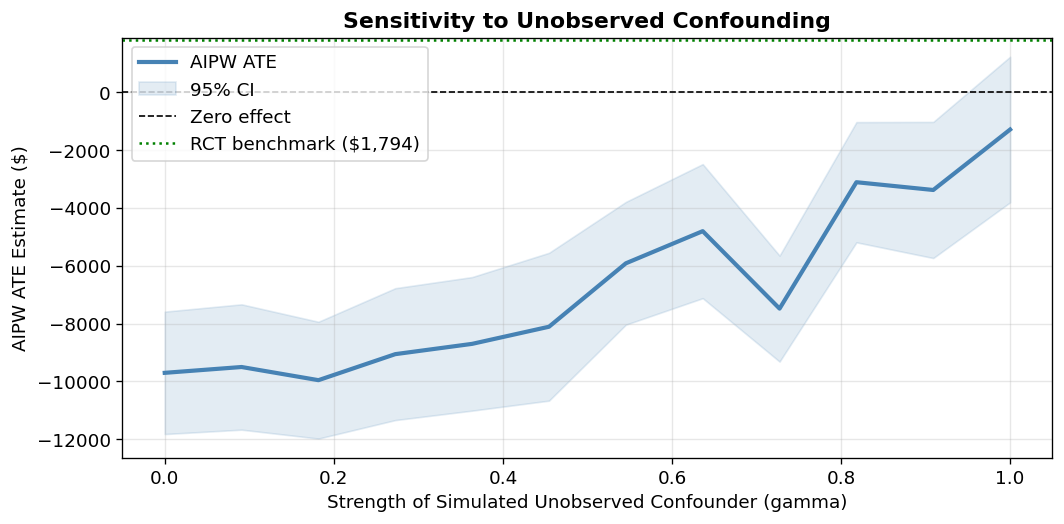

In [28]:
# ── Test 3: Unobserved confounder sensitivity curve ───────────────────────────
print("Test 3: Unobserved confounder sensitivity...")
gammas    = np.linspace(0, 1.0, 12)
sens_ates = []; sens_lo = []; sens_hi = []
Y_sd = Y.std()
np.random.seed(2)

for gamma in gammas:
    U            = (gamma*(T-T.mean()) + np.random.normal(0, 0.5, n) > 0).astype(float)
    Y_conf       = Y + gamma * Y_sd * (U - U.mean())
    a, se        = run_aipw(X, T, Y_conf, K=3, seed=42)
    sens_ates.append(a); sens_lo.append(a - 1.96*se); sens_hi.append(a + 1.96*se)
    print(f"  gamma={gamma:.2f}  ATE=${a:,.0f}")

sens_ates = np.array(sens_ates)
sens_lo   = np.array(sens_lo)
sens_hi   = np.array(sens_hi)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(gammas, sens_ates, color='steelblue', linewidth=2.5, label='AIPW ATE')
ax.fill_between(gammas, sens_lo, sens_hi, alpha=0.15, color='steelblue', label='95% CI')
ax.axhline(0,             color='black', linewidth=1,   linestyle='--', label='Zero effect')
ax.axhline(RCT_BENCHMARK, color='green', linewidth=1.5, linestyle=':',
           label=f'RCT benchmark (${RCT_BENCHMARK:,})')
ax.set_xlabel('Strength of Simulated Unobserved Confounder (gamma)')
ax.set_ylabel('AIPW ATE Estimate ($)')
ax.set_title('Sensitivity to Unobserved Confounding', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/refute_sensitivity.png', bbox_inches='tight')
plt.show()

---
## References

- LaLonde, R.J. (1986). Evaluating the econometric evaluations of training programs. *AER*, 76(4), 604–620.
- Dehejia, R.H., & Wahba, S. (1999). Causal effects in nonexperimental studies. *JASA*, 94(448), 1053–1062.
- Wager, S., & Athey, S. (2018). Estimation and inference of heterogeneous treatment effects. *JASA*, 113(523), 1228–1242.
- Sharma, A., & Kiciman, E. (2020). DoWhy: An end-to-end library for causal inference. arXiv:2011.04216.
- Kennedy, E.H. (2020). Optimal doubly robust estimation of heterogeneous causal effects. arXiv:2004.14497.